In [1]:
"""Perform regularised CT reconstruction."""

'Perform regularised CT reconstruction.'

In [2]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

from common.operators import derivative_operator, identity_operator, perona_malik_operator
from common.radon import add_noise_to_sinogram, radon, iradon
from solvers.least_square import LSQRSolver
from evaluation.tuning import StandardTuner, IterativeTuner

In [3]:
"""Read Shepp-Logan phantom and set background intensity."""

f = np.load("../../data/shepp_logan.npy")
I_0 = 1e4

In [4]:
"""Set up operators for limited view reconstruction."""

scanner_properties = {
    "views": 45,
    "angle": 180,
    "detector_count": 128,
    "detector_spacing": 1,
    "beam_geometry": "parallel",
}

# Forward operator
forward = partial(radon, **scanner_properties)

# Backward operators
backward = partial(
    iradon,
    img_dims=f.shape,
    recon_type="BP",
    **scanner_properties,
)
filtered_backward = partial(
    iradon,
    img_dims=f.shape,
    recon_type="FBP",
    **scanner_properties,
)

In [5]:
"""Get sinogram, add noise and set up tuner."""
g = forward(f)
g = add_noise_to_sinogram(g, background_intensity=I_0)

lsqr_tuner = StandardTuner(
    solver=LSQRSolver,
    g=g,
    A=forward,
    AT=backward,
    x_dims=f.shape,
    tuning_metric="SSIM",  
    f=f,
)

[INFO] 2025-02-25 13:18:01 | Alpha 0.5: SSIM 0.43157001647471527 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:05 | Alpha 1.0: SSIM 0.44068534063787185 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:09 | Alpha 5.0: SSIM 0.46115424145855044 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:11 | Alpha 10.0: SSIM 0.47773864224464296 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:12 | Alpha 50.0: SSIM 0.5357907843865015 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:13 | Alpha 100.0: SSIM 0.5321197339350694 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:13 | Alpha 500.0: SSIM 0.3801756947358597 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:14 | Alpha 1000.0: SSIM 0.32858593375091705 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:14 | Alpha 5000.0: SSIM 0.22840347603036243 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:14 |

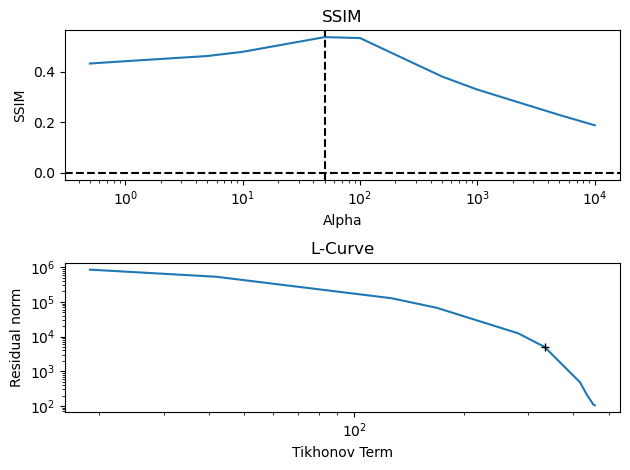

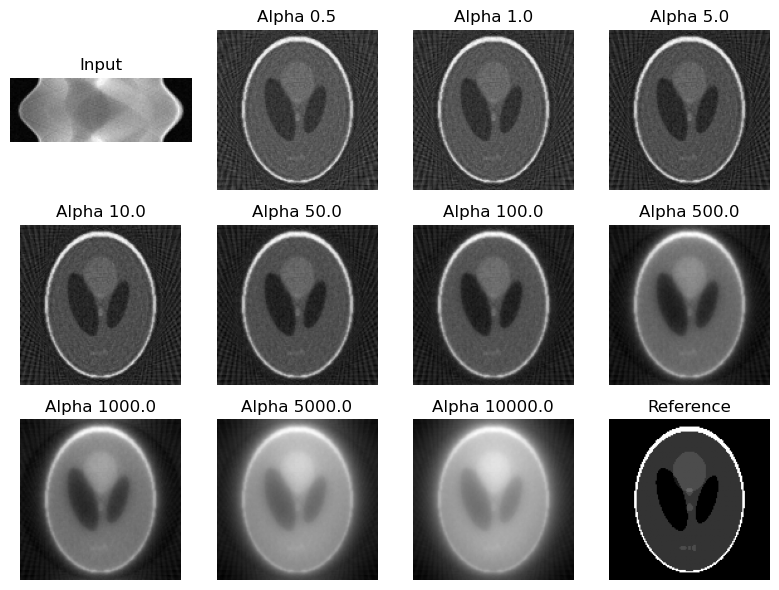

Optimal alpha: 50.0


In [6]:
"""Find optimal alpha using LSQR and TK0"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=identity_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
tk0_f_hat = lsqr_tuner._optimal_f_hat


[INFO] 2025-02-25 13:18:21 | Alpha 0.5: SSIM 0.43834220179204375 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:24 | Alpha 1.0: SSIM 0.44810001222727613 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:28 | Alpha 5.0: SSIM 0.49201415843886365 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:32 | Alpha 10.0: SSIM 0.5289019042236112 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:34 | Alpha 50.0: SSIM 0.6584782974343316 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:35 | Alpha 100.0: SSIM 0.7031950957663032 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:37 | Alpha 500.0: SSIM 0.6833048331348607 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:39 | Alpha 1000.0: SSIM 0.6322717466240434 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:41 | Alpha 5000.0: SSIM 0.498120859828711 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:44 | Alp

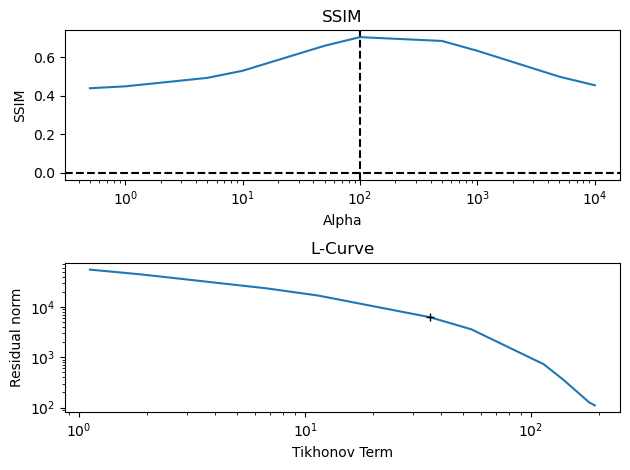

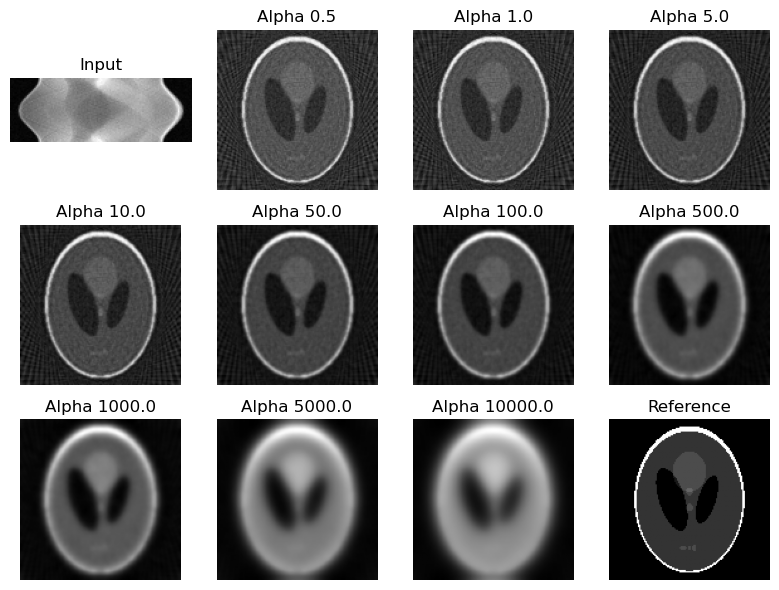

Optimal alpha: 100.0


In [7]:
"""Find optimal alpha using LSQR and TK1"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=derivative_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
tk1_f_hat = lsqr_tuner._optimal_f_hat


[INFO] 2025-02-25 13:18:51 | Alpha 0.5: SSIM 0.5057739086042238 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:18:57 | Alpha 1.0: SSIM 0.522079583750092 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:02 | Alpha 5.0: SSIM 0.569019745943126 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:06 | Alpha 10.0: SSIM 0.607259602599071 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:08 | Alpha 50.0: SSIM 0.7218283664949607 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:09 | Alpha 100.0: SSIM 0.755890506549126 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:11 | Alpha 500.0: SSIM 0.7309299233507073 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:13 | Alpha 1000.0: SSIM 0.6773500682552914 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:16 | Alpha 5000.0: SSIM 0.5331102763679317 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:19:19 | Alpha 100

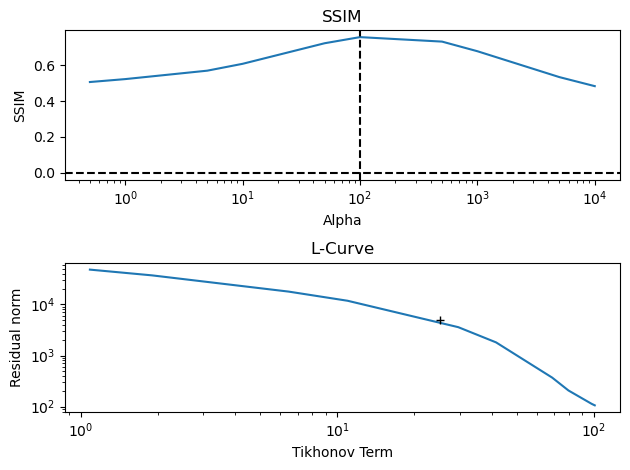

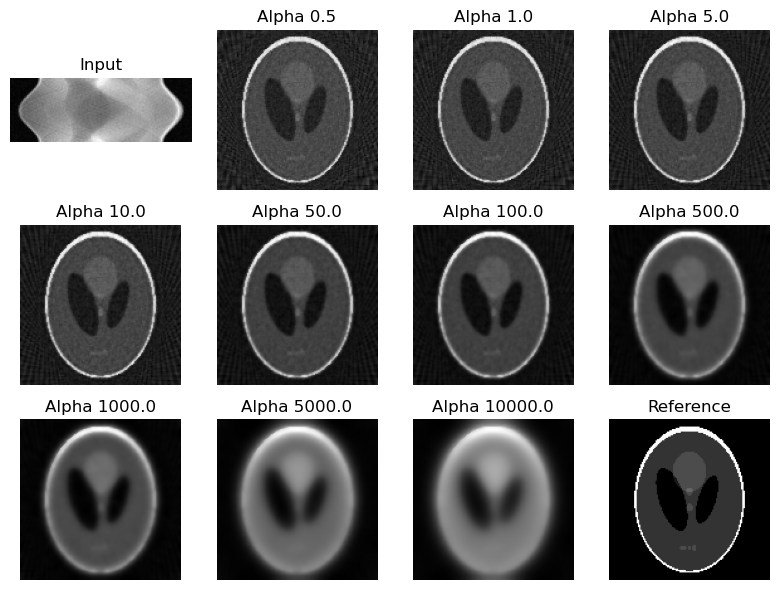

Optimal alpha: 100.0


In [8]:
"""Find optimal alpha using LSQR and Perona-Malik"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
pm_f_hat = lsqr_tuner._optimal_f_hat


[INFO] 2025-02-25 13:19:52 | Alpha 0.5: SSIM 0.49761114447900884 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:20:22 | Alpha 1.0: SSIM 0.515473331818185 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:20:46 | Alpha 5.0: SSIM 0.5713139583460652 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:21:11 | Alpha 10.0: SSIM 0.6054943612103926 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:21:33 | Alpha 50.0: SSIM 0.7095537744638779 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:21:59 | Alpha 100.0: SSIM 0.7447453790183215 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:22:45 | Alpha 500.0: SSIM 0.7211419029473868 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:23:07 | Alpha 1000.0: SSIM 0.6697549154397218 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:24:26 | Alpha 5000.0: SSIM 0.5342603598552285 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:26:11 | Alpha

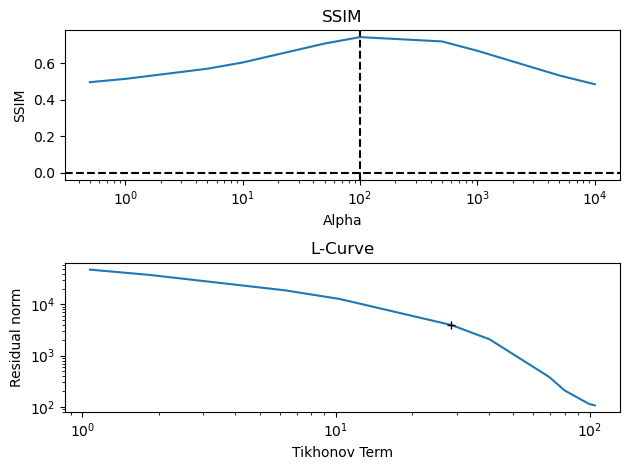

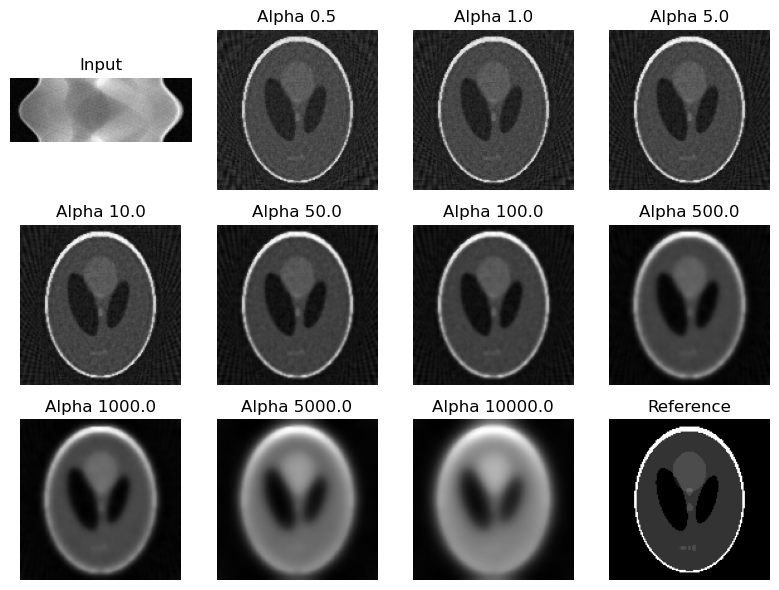

Optimal alpha: 100.0


In [9]:
"""Find optimal alpha using LSQR and iterative Perona-Malik"""

lsqr_tuner = IterativeTuner(
    solver=LSQRSolver,
    g=g,
    A=forward,
    AT=backward,
    x_dims=f.shape,
    tuning_metric="SSIM",
    f=f,
)

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
iter_pm_f_hat = lsqr_tuner._optimal_f_hat


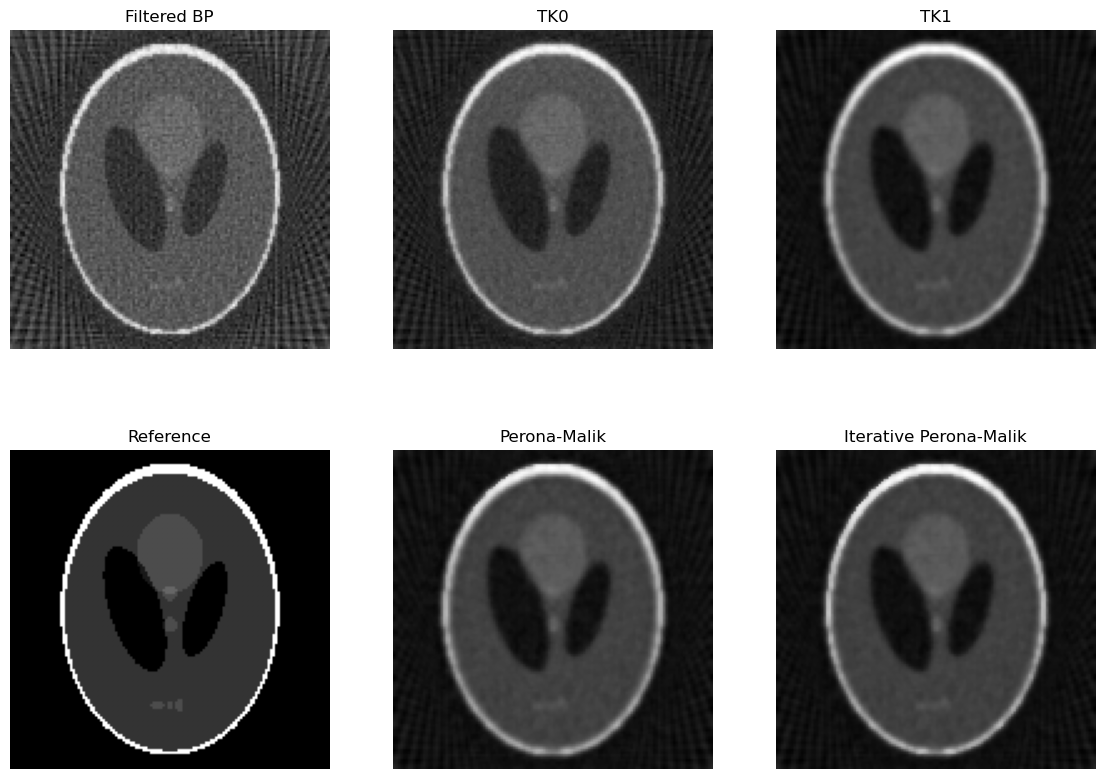

In [10]:
"""Compare different techniques"""

x_slice = slice(None, None)
y_slice = slice(None, None)
# x_slice = slice(0, 64)
# y_slice = slice(32, 96)

_, axs = plt.subplots(2, 3, figsize=(14, 10))
axs[0, 0].imshow(filtered_backward(g)[x_slice, y_slice], cmap="gray")
axs[0, 0].set_title("Filtered BP")
axs[0, 0].axis("off")
axs[0, 1].imshow(tk0_f_hat[x_slice, y_slice], cmap="gray")
axs[0, 1].set_title("TK0")
axs[0, 1].axis("off")
axs[0, 2].imshow(tk1_f_hat[x_slice, y_slice], cmap="gray")
axs[0, 2].set_title("TK1")
axs[0, 2].axis("off")
axs[1, 0].imshow(f[x_slice, y_slice], cmap="gray")
axs[1, 0].set_title("Reference")
axs[1, 0].axis("off")
axs[1, 1].imshow(pm_f_hat[x_slice, y_slice], cmap="gray")
axs[1, 1].set_title("Perona-Malik")
axs[1, 1].axis("off")
axs[1, 2].imshow(iter_pm_f_hat[x_slice, y_slice], cmap="gray")
axs[1, 2].set_title("Iterative Perona-Malik")
axs[1, 2].axis("off")
plt.show()

In [11]:
"""Show limited angle reconstructions."""

scanner_properties = {
    "views": 90,
    "angle": 90,
    "detector_count": 128,
    "detector_spacing": 1,
    "beam_geometry": "parallel",
}

# Forward operator
forward = partial(radon, **scanner_properties)

# Backward operators
backward = partial(
    iradon,
    img_dims=f.shape,
    recon_type="BP",
    **scanner_properties,
)

filtered_backward = partial(
    iradon,
    img_dims=f.shape,
    recon_type="FBP",
    **scanner_properties,
)

In [12]:
"""Get sinogram, add noise and set up tuner."""
g = forward(f)
g = add_noise_to_sinogram(g, background_intensity=I_0)

lsqr_tuner = StandardTuner(
    solver=LSQRSolver,
    g=g,
    A=forward,
    AT=backward,
    x_dims=f.shape,
    tuning_metric="SSIM",  
    f=f,
)

[INFO] 2025-02-25 13:26:44 | Alpha 0.5: SSIM 0.21434137688223853 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:26:51 | Alpha 1.0: SSIM 0.23734041256262123 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:26:58 | Alpha 5.0: SSIM 0.30653827137657025 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:08 | Alpha 10.0: SSIM 0.33562410761834377 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:11 | Alpha 50.0: SSIM 0.3936814850216054 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:14 | Alpha 100.0: SSIM 0.4098636402200362 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:16 | Alpha 500.0: SSIM 0.3919344038724432 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:17 | Alpha 1000.0: SSIM 0.36756785645048407 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:18 | Alpha 5000.0: SSIM 0.31116472382530086 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:18 |

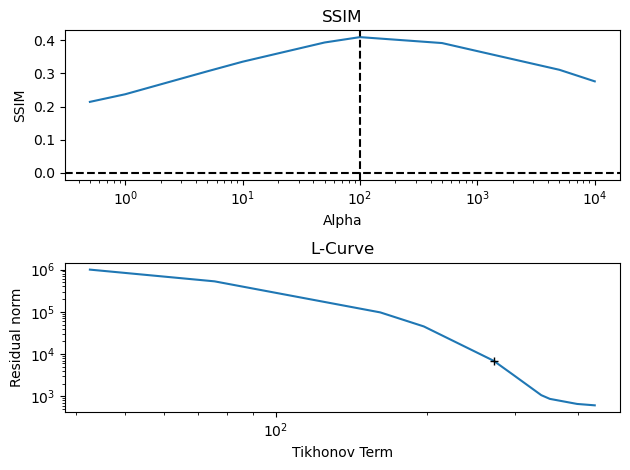

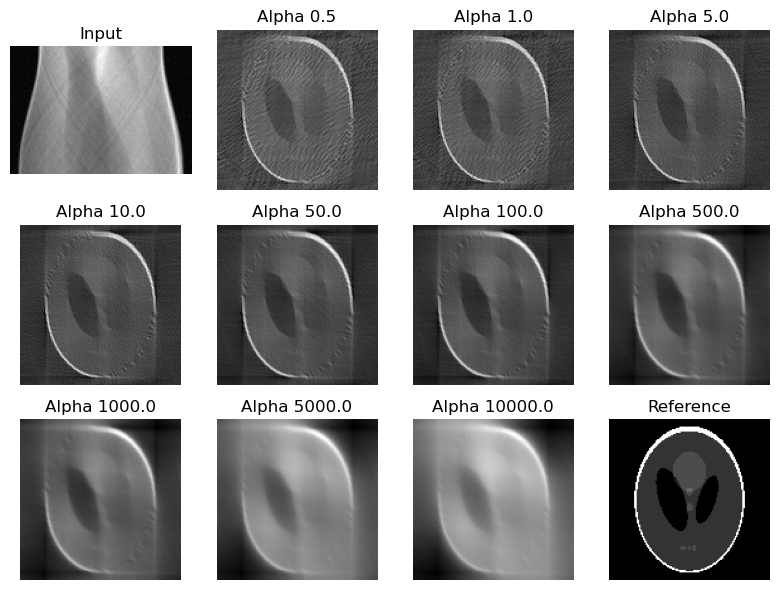

Optimal alpha: 100.0


In [13]:
"""Find optimal alpha using LSQR and TK0"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=identity_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
tk0_f_hat = lsqr_tuner._optimal_f_hat

[INFO] 2025-02-25 13:27:30 | Alpha 0.5: SSIM 0.26054473794318533 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:36 | Alpha 1.0: SSIM 0.2914792047317914 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:43 | Alpha 5.0: SSIM 0.3745626225376199 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:51 | Alpha 10.0: SSIM 0.41585654742448025 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:27:58 | Alpha 50.0: SSIM 0.4947361426615974 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:05 | Alpha 100.0: SSIM 0.509772788727931 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:11 | Alpha 500.0: SSIM 0.4827939421369869 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:18 | Alpha 1000.0: SSIM 0.46756902799387023 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:25 | Alpha 5000.0: SSIM 0.4030255299964436 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:31 | Alp

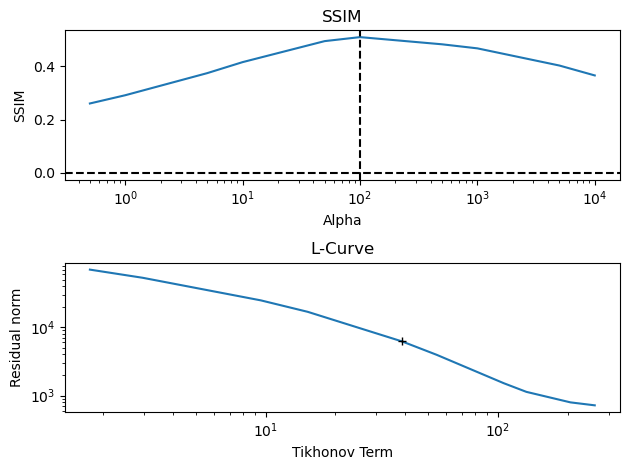

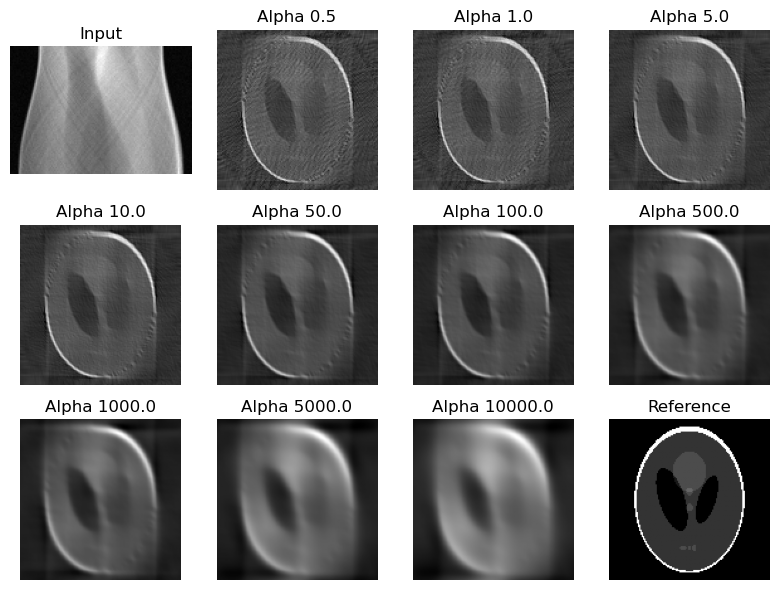

Optimal alpha: 100.0


In [14]:
"""Find optimal alpha using LSQR and TK1"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=derivative_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
tk1_f_hat = lsqr_tuner._optimal_f_hat

[INFO] 2025-02-25 13:28:46 | Alpha 0.5: SSIM 0.2604387996203026 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:28:52 | Alpha 1.0: SSIM 0.2870200698741792 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:01 | Alpha 5.0: SSIM 0.37321650431650494 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:07 | Alpha 10.0: SSIM 0.41680315158708625 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:14 | Alpha 50.0: SSIM 0.4958003400849229 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:21 | Alpha 100.0: SSIM 0.5134150031819023 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:27 | Alpha 500.0: SSIM 0.4896641450583696 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:34 | Alpha 1000.0: SSIM 0.47195237180618715 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:41 | Alpha 5000.0: SSIM 0.4321846387550757 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:29:47 | Al

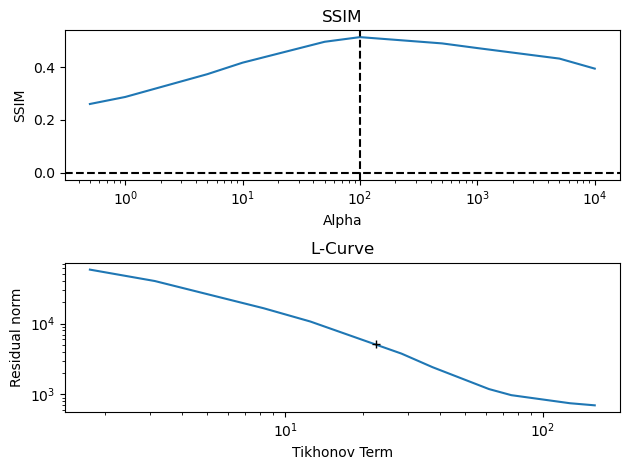

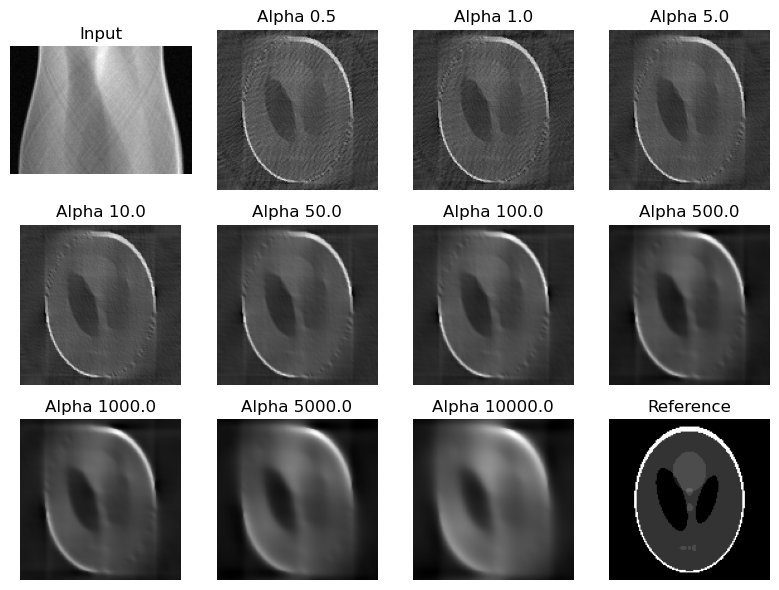

Optimal alpha: 100.0


In [15]:
"""Find optimal alpha using LSQR and Perona-Malik"""

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
pm_f_hat = lsqr_tuner._optimal_f_hat

[INFO] 2025-02-25 13:32:56 | Alpha 0.5: SSIM 0.22709444250772742 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:35:58 | Alpha 1.0: SSIM 0.2720814222316117 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:37:28 | Alpha 5.0: SSIM 0.3841561849518204 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:47:35 | Alpha 10.0: SSIM 0.43182570775051493 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:48:14 | Alpha 50.0: SSIM 0.5027962425396422 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:48:54 | Alpha 100.0: SSIM 0.5099860309160321 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:50:06 | Alpha 500.0: SSIM 0.48549191010745885 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:51:15 | Alpha 1000.0: SSIM 0.4709914850822279 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:52:45 | Alpha 5000.0: SSIM 0.42328684513845516 | evaluation.eval_metrics-log_metrics:205
[INFO] 2025-02-25 13:53:51 | A

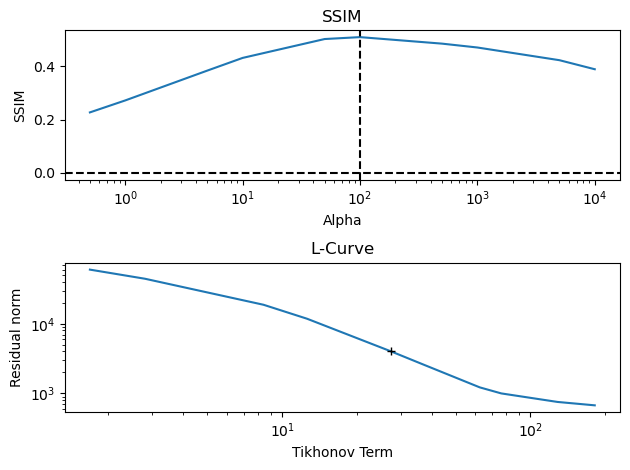

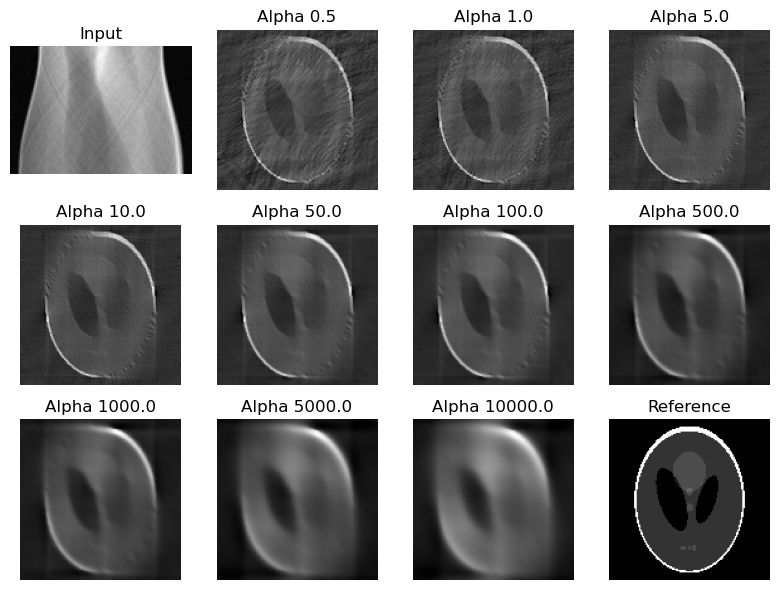

Optimal alpha: 100.0


In [16]:
"""Find optimal alpha using LSQR and iterative Perona-Malik"""

lsqr_tuner = IterativeTuner(
    solver=LSQRSolver,
    g=g,
    A=forward,
    AT=backward,
    x_dims=f.shape,
    tuning_metric="SSIM",
    f=f,
)

alphas = [5e-1, 1e0, 5e0, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]

lsqr_tuner.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=filtered_backward(g),
    save_imgs=True,
)
lsqr_tuner.display_metrics()
lsqr_tuner.display_sample()
print(f"Optimal alpha: {lsqr_tuner.optimal_alpha}")
iter_pm_f_hat = lsqr_tuner._optimal_f_hat

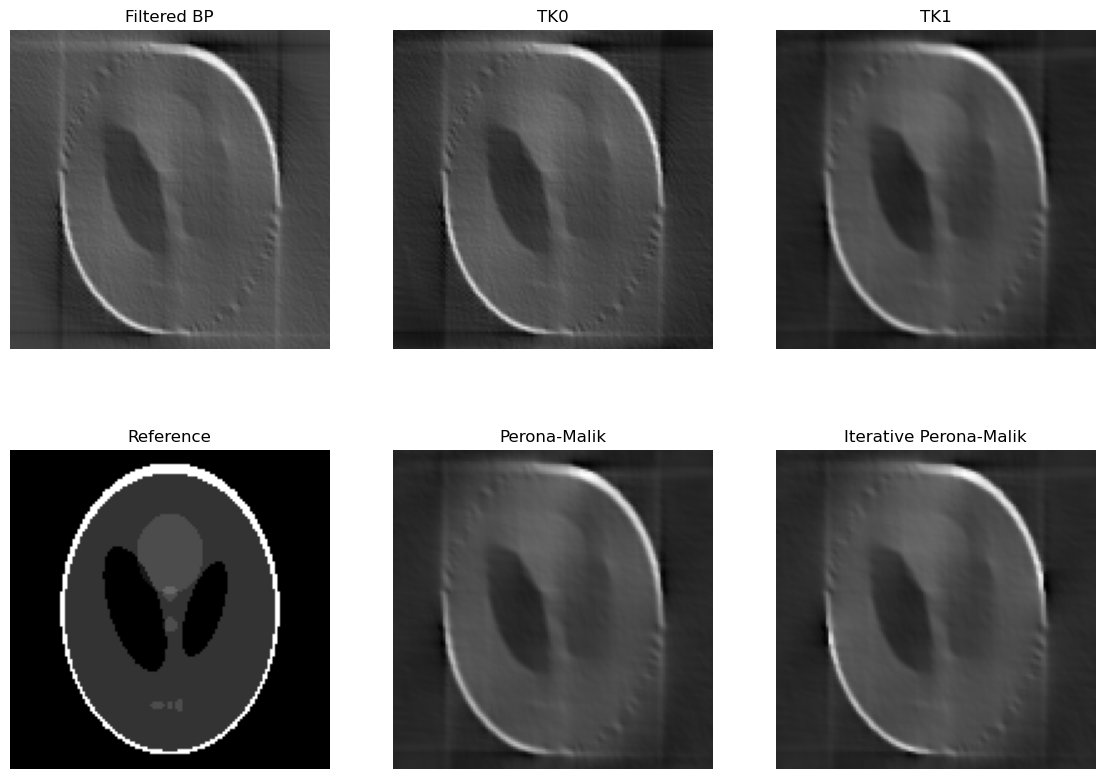

In [17]:
"""Compare different techniques"""

x_slice = slice(None, None)
y_slice = slice(None, None)
# x_slice = slice(0, 64)
# y_slice = slice(32, 96)

_, axs = plt.subplots(2, 3, figsize=(14, 10))
axs[0, 0].imshow(filtered_backward(g)[x_slice, y_slice], cmap="gray")
axs[0, 0].set_title("Filtered BP")
axs[0, 0].axis("off")
axs[0, 1].imshow(tk0_f_hat[x_slice, y_slice], cmap="gray")
axs[0, 1].set_title("TK0")
axs[0, 1].axis("off")
axs[0, 2].imshow(tk1_f_hat[x_slice, y_slice], cmap="gray")
axs[0, 2].set_title("TK1")
axs[0, 2].axis("off")
axs[1, 0].imshow(f[x_slice, y_slice], cmap="gray")
axs[1, 0].set_title("Reference")
axs[1, 0].axis("off")
axs[1, 1].imshow(pm_f_hat[x_slice, y_slice], cmap="gray")
axs[1, 1].set_title("Perona-Malik")
axs[1, 1].axis("off")
axs[1, 2].imshow(iter_pm_f_hat[x_slice, y_slice], cmap="gray")
axs[1, 2].set_title("Iterative Perona-Malik")
axs[1, 2].axis("off")
plt.show()

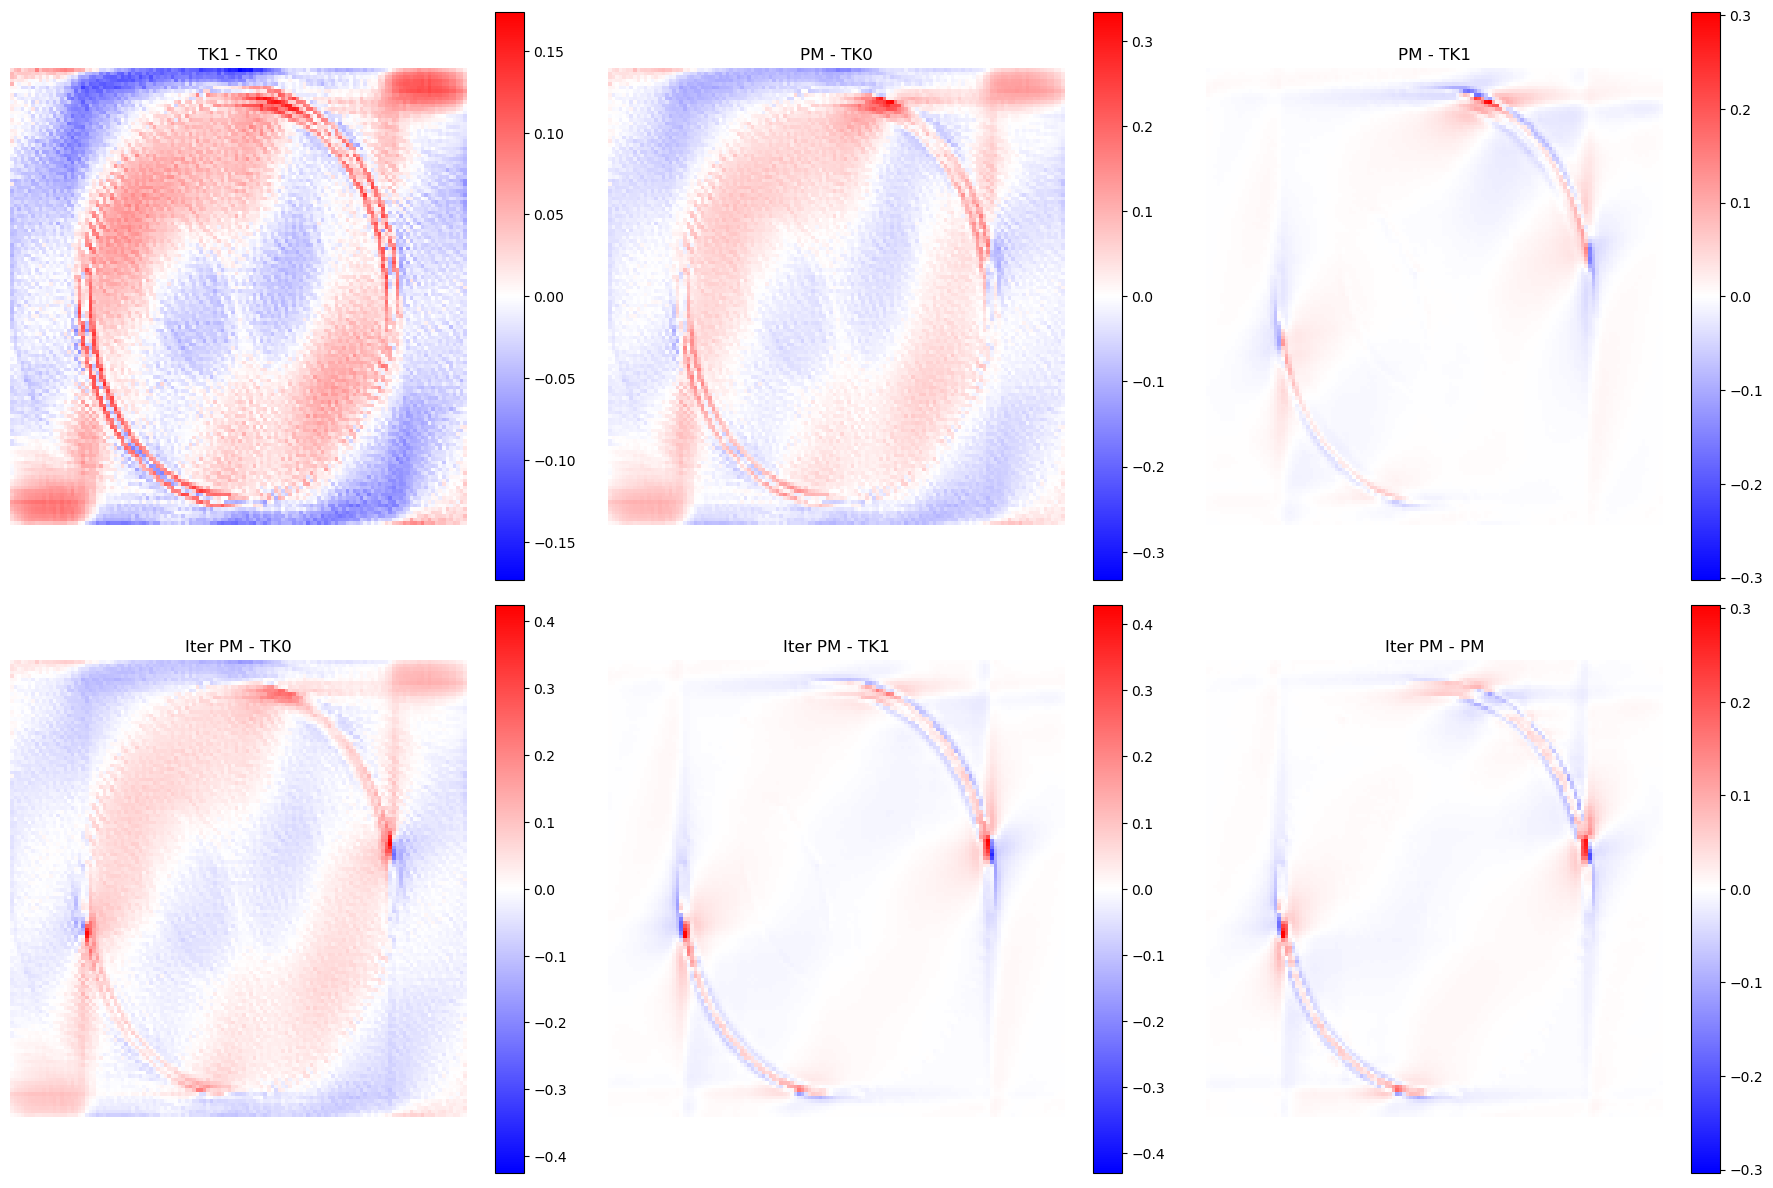

In [18]:
"""Compare errors between each technique"""

from matplotlib.colors import CenteredNorm

x_slice = slice(None, None)
y_slice = slice(None, None)
# x_slice = slice(50, 150)
# y_slice = slice(80, 180)

plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(tk1_f_hat[x_slice, y_slice] - tk0_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("TK1 - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 2)
plt.imshow(pm_f_hat[x_slice, y_slice] - tk0_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("PM - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 3)
plt.imshow(pm_f_hat[x_slice, y_slice] - tk1_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("PM - TK1")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 4)
plt.imshow(iter_pm_f_hat[x_slice, y_slice] - tk0_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 5)
plt.imshow(iter_pm_f_hat[x_slice, y_slice] - tk1_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - TK1")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 6)
plt.imshow(iter_pm_f_hat[x_slice, y_slice] - pm_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - PM")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.tight_layout()
plt.show()
